# Bloque 2 — OMP y K-SVD

Entrena un diccionario de 128 átomos (64-D) con un ciclo K-SVD propio: codificación dispersa con `sklearn.linear_model.orthogonal_mp` y actualización átomo por átomo con `numpy.linalg.svd` sobre el residual restringido.

Implementación: `src/modelo.py`. Productos: `modelo.npz`, `historial.csv`, `config_efectiva.json`, `figuras/`. Documentación: `nota_metodo.md`.

In [1]:
# Localiza la raíz del repositorio (local o Kaggle) y la añade a sys.path.
import os, sys, subprocess
from pathlib import Path

REPO_URL = "https://github.com/SarahVasquezM/ksvd-image-denoising.git"
REPO_REF = os.environ.get("KSVD_REPO_REF", "codex/auditoria-final")

def find_root():
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "src" / "modelo.py").exists():
            return p
    if Path("/kaggle/working").exists():          # Kaggle: clonar el repositorio
        dest = Path("/kaggle/working/ksvd-image-denoising")
        if not dest.exists():
            subprocess.run(["git", "clone", "--depth", "1", "--branch", REPO_REF,
                            REPO_URL, str(dest)], check=True)
        return dest
    raise FileNotFoundError("No se encontró la raíz del repositorio")

ROOT = find_root()
sys.path.insert(0, str(ROOT))
import warnings
# Mostrar advertencias sin rutas absolutas de la máquina (no se suprime ninguna).
warnings.formatwarning = lambda msg, cat, filename, lineno, line=None: (
    f"{cat.__name__} ({Path(filename).name}:{lineno}): {msg}\n")
from threadpoolctl import threadpool_limits
from src.pipeline import DEFAULT_THREADS, paths
threadpool_limits(limits=DEFAULT_THREADS)     # evita sobresuscripción BLAS con matrices pequeñas
P = paths(ROOT)
print("Raíz del repositorio:", ROOT.name)

Raíz del repositorio: ksvd-auditoria-final


## 1. Entrenamiento (mide primero; la contingencia sólo se activa si el tiempo proyectado excede el presupuesto)

In [2]:
import json, pandas as pd
from src.pipeline import run_block2
res = run_block2(ROOT)
eff = res["effective"]
print("Nivel de contingencia:", eff["contingency_level"], "-", eff["contingency_label"])
print(f"K={eff['n_atoms']}  N={eff['n_train_patches']}  iter={eff['n_iter']}  T={eff['train_sparsity']}  "
      f"tiempo={eff['training_time_s']:.2f}s")

RuntimeWarning (modelo.py:206): OMP terminó antes de 4 átomos en 128 señal(es) (residual nulo o dependencia lineal); max_nonzero es un máximo.


iter 1: mse=5.604473e-04 t=0.21s sin_uso=0


iter 2: mse=4.229563e-04 t=0.51s sin_uso=0


iter 3: mse=3.796942e-04 t=0.76s sin_uso=0


iter 4: mse=3.638848e-04 t=1.01s sin_uso=0


...

iter 6: mse=3.472041e-04 t=1.44s sin_uso=0


iter 7: mse=3.399084e-04 t=1.66s sin_uso=0


iter 8: mse=3.382060e-04 t=1.93s sin_uso=0


RuntimeWarning (modelo.py:302): OMP terminó antes de 4 átomos en 128 señal(es) (residual nulo o dependencia lineal); max_nonzero es un máximo.


Nivel de contingencia: 0 - configuración deseada
K=128  N=1500  iter=8  T=4  tiempo=2.09s


In [3]:
pd.read_csv(P["historial"])

,iteration,train_mse,elapsed_s,unused_atoms
0,1,0.000560,0.212636,0
1,2,0.000423,0.509166,0
2,3,0.000380,0.764353,0
3,4,0.000364,1.013478,0
4,5,0.000353,1.227855,0
5,6,0.000347,1.439893,0
6,7,0.000340,1.659424,0
7,8,0.000338,1.925225,0


## 2. Validaciones del modelo

In [4]:
print(json.dumps(eff["checks"], indent=2))
print("MSE con D_init:", eff["train_mse_init_dictionary"], " | MSE final recodificado:", eff["train_mse_final_recoded"])

{
  "D_shape_ok": true,
  "D_unit_norm_max_dev": 7.771561172376096e-16,
  "D_finite": true,
  "A_shape_ok": true,
  "A_finite": true,
  "max_active_per_column": 4,
  "recon_shape_ok": true,
  "train_mse_final": 0.00034132384459536715
}
MSE con D_init: 0.000954902109100754  | MSE final recodificado: 0.00034132384459536715


## 3. Comprobación de la actualización de soporte fijo (SVD = mejor aproximación de rango 1)

In [5]:
import numpy as np
from src.modelo import load_model, sparse_code, ksvd_dictionary_update, rank1_atom_update
from src.preprocesamiento import load_dataset
X = load_dataset(P["datos"])["X_train"][:, :eff["n_train_patches"]]
m = load_model(P["modelo"])
D = m["D_init"]; A = sparse_code(D, X, eff["train_sparsity"])
j = int(np.argmax(np.sum(A != 0, axis=1)))
omega = np.flatnonzero(A[j] != 0)
E = X[:, omega] - D @ A[:, omega] + np.outer(D[:, j], A[j, omega])
d, a = rank1_atom_update(E)
s = np.linalg.svd(E, compute_uv=False)
print(f"átomo {j}: |omega|={omega.size}, ||E - d a^T||^2 = {np.linalg.norm(E - np.outer(d, a))**2:.6e}, "
      f"sum(s[1:]^2) = {np.sum(s[1:]**2):.6e}")
before = np.linalg.norm(X - D @ A)
D2, A2, info = ksvd_dictionary_update(X, D, A)
print(f"||X - DA||_F antes={before:.6f}  después de una pasada={np.linalg.norm(X - D2 @ A2):.6f}  info={info}")

átomo 94: |omega|=137, ||E - d a^T||^2 = 6.931472e+00, sum(s[1:]^2) = 6.931472e+00


||X - DA||_F antes=9.574477  después de una pasada=7.335049  info={'unused_atoms': 0, 'reinitialized_atoms': 0}


RuntimeWarning (1628194509.py:6): OMP terminó antes de 4 átomos en 128 señal(es) (residual nulo o dependencia lineal); max_nonzero es un máximo.


## 4. Figuras

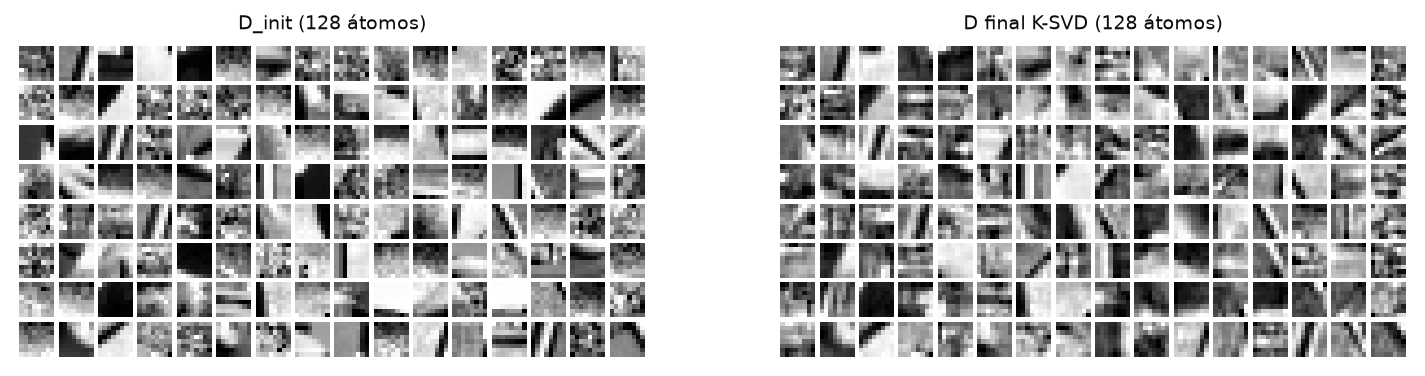

In [6]:
from IPython.display import Image, display
display(Image(filename=str(ROOT / "02_modelo/figuras/diccionario_inicial_vs_final.png")))

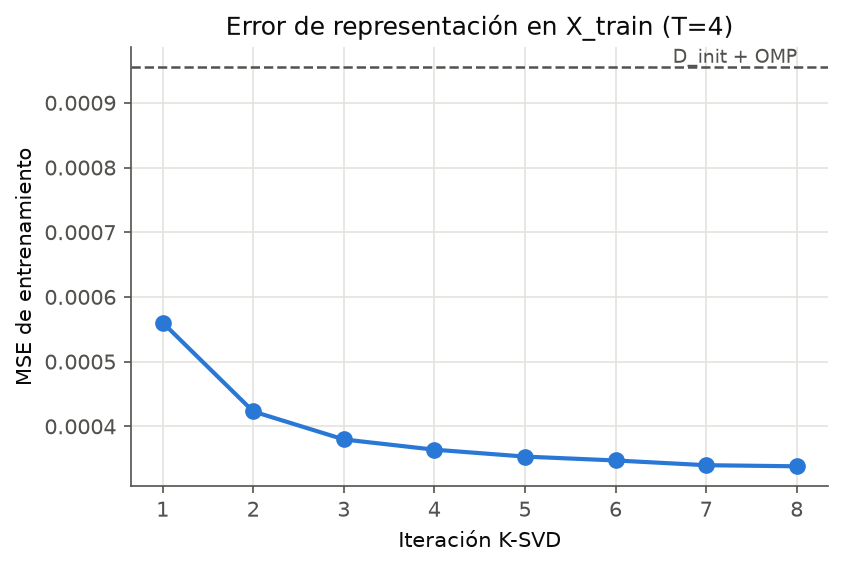

In [7]:
from IPython.display import Image, display
display(Image(filename=str(ROOT / "02_modelo/figuras/curva_entrenamiento.png")))

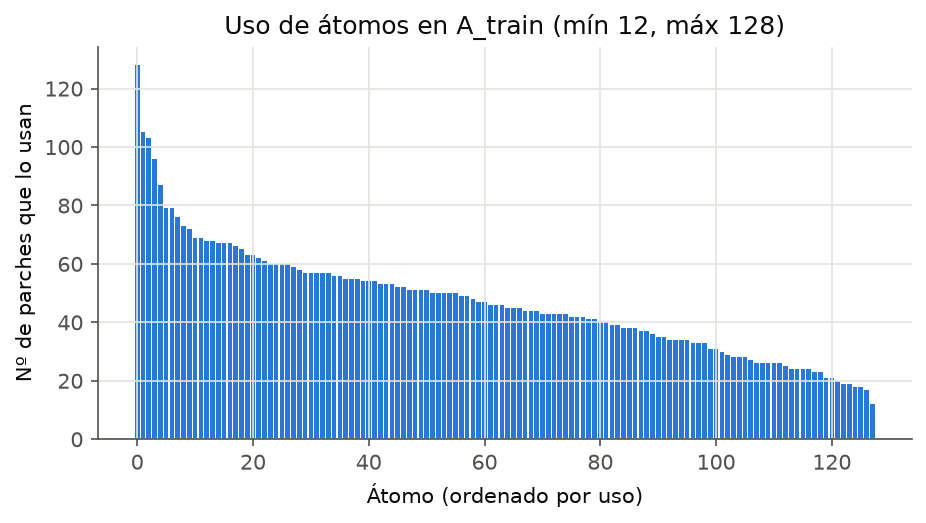

In [8]:
from IPython.display import Image, display
display(Image(filename=str(ROOT / "02_modelo/figuras/uso_atomos.png")))